In [42]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)
 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [43]:

# 1. CARGA Y EXPLORACIÓN DEL DATASET


#https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection

def load_dataset(filepath="Sarcasm_Headlines_Dataset_v2.json"):
    """
    Carga el JSON línea por línea. Cada línea tiene:
      - headline:     texto del titular de noticia
      - is_sarcastic: 1 = irónico (The Onion), 0 = serio (HuffPost)
    """
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line.strip()))
    df = pd.DataFrame(records)
    return df[["headline", "is_sarcastic"]]

df = load_dataset()

df["num_words"] = df["headline"].apply(lambda x: len(x.split()))

print(f"\n -Total de ejemplos-     : {len(df):,}")
print(f"   Irónicos   (clase 1)  : {df['is_sarcastic'].sum():,}  "
      f"({df['is_sarcastic'].mean()*100:.1f}%)")
print(f"   No irónicos (clase 0) : {(df['is_sarcastic']==0).sum():,}  "
      f"({(1-df['is_sarcastic'].mean())*100:.1f}%)")
print(f"\n -Longitud promedio-     : {df['num_words'].mean():.1f} palabras")
print(f"   Máximo               : {df['num_words'].max()} palabras")

print("\n -Ejemplos IRÓNICOS:-")
for h in df[df["is_sarcastic"]==1]["headline"].sample(3, random_state=42).values:
    print(f"   {h}")

print("\n -Ejemplos SERIOS:-")
for h in df[df["is_sarcastic"]==0]["headline"].sample(3, random_state=42).values:
    print(f"   {h}")




 -Total de ejemplos-     : 28,619
   Irónicos   (clase 1)  : 13,634  (47.6%)
   No irónicos (clase 0) : 14,985  (52.4%)

 -Longitud promedio-     : 10.0 palabras
   Máximo               : 151 palabras

 -Ejemplos IRÓNICOS:-
   male friends depart for annual camping trip to complain about camping
   everything reminds man of 'her'
   longtime sexual fantasy awkwardly fulfilled

 -Ejemplos SERIOS:-
   this artist gives renaissance-style sculptures a goofy modern twist
   what's leaving netflix in may 2016?
   dogs in asia: doctors not dinner


In [44]:
# 2. DIVISIÓN TRAIN / TEST

"""
Usamos la misma división para todos los modelos (misma semilla)
para que las comparaciones sean JUSTAS.
  - 70% entrenamiento
  - 10% validación  (solo para LSTM)
  - 20% test final
"""

X = df["headline"].values
y = df["is_sarcastic"].values

# Primera división: 80% train+val / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segunda división: 87.5% train / 12.5% val (del 80% → 70/10 del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print(f"\n Train      : {len(X_train):,} ejemplos  ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Validation : {len(X_val):,}  ejemplos  ({len(X_val)/len(X)*100:.0f}%)")
print(f"   Test       : {len(X_test):,} ejemplos  ({len(X_test)/len(X)*100:.0f}%)")



 Train      : 20,033 ejemplos  (70%)
   Validation : 2,862  ejemplos  (10%)
   Test       : 5,724 ejemplos  (20%)


In [45]:
# 3. VECTORIZACIÓN PARA MODELOS CLÁSICOS

"""
TF-IDF con unigramas + bigramas:
  - Convierte texto en vector numérico de 15,000 dimensiones
  - Cada dimensión representa el peso TF-IDF de un término
  - Los modelos clásicos (SVM, LR, NB, RF) trabajan con esta representación
  
  NOTA: Naive Bayes requiere CountVectorizer (conteos enteros, no TF-IDF)
        porque se basa en probabilidades de ocurrencia de palabras.
"""

# TF-IDF para SVM, LR, RF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode"
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer para Naive Bayes (necesita conteos no negativos)
count_vec = CountVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode"
)
X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print(f" TF-IDF shape   : {X_train_tfidf.shape}")
print(f" CountVec shape : {X_train_count.shape}")

 TF-IDF shape   : (20033, 15000)
 CountVec shape : (20033, 15000)


In [46]:

# 4. TOKENIZACIÓN PARA LSTM

"""
Las Redes Recurrentes (LSTM) NO usan TF-IDF.
Necesitan secuencias de índices enteros:
  - Cada palabra → índice único en el vocabulario
  - Cada titular → lista de índices de longitud fija (padding)
  
Ventaja del LSTM: aprende el ORDEN y CONTEXTO de las palabras,
no solo su presencia (como TF-IDF).
"""

VOCAB_SIZE = 20000   # tamaño del vocabulario
MAX_LEN    = 30      # longitud máxima de secuencia (la mayoría de titulares < 20 palabras)
EMBED_DIM  = 64      # dimensión del embedding (representación densa de cada palabra)

tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(X_train)  # aprende el vocabulario solo del train

# Convertir textos a secuencias de índices
X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq   = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding="post", truncating="post")

print(f" Vocabulario aprendido : {len(tokenizer_lstm.word_index):,} palabras únicas")
print(f"   Vocabulario usado    : {VOCAB_SIZE:,} (más frecuentes)")
print(f"   MAX_LEN              : {MAX_LEN} tokens por secuencia")
print(f"   Shape X_train_seq    : {X_train_seq.shape}")
print(f"\n   Ejemplo — '{X_train[0]}'")
print(f"    índices: {X_train_seq[0][:10]}...")



 Vocabulario aprendido : 25,948 palabras únicas
   Vocabulario usado    : 20,000 (más frecuentes)
   MAX_LEN              : 30 tokens por secuencia
   Shape X_train_seq    : (20033, 30)

   Ejemplo — 'report: 96% of nation's smut consumed by filthiest 1%'
    índices: [   36  3832     3   209 13009  5813    18 13010   254     0]...


In [47]:
# 5. ENTRENAMIENTO DE MODELOS CLÁSICOS

# ── Diccionario para guardar resultados ──
results = {}

def evaluar(nombre, y_true, y_pred, y_proba=None):
    """Calcula y almacena métricas para un modelo."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    results[nombre] = {
        "accuracy": acc, "f1": f1, "auc": auc,
        "y_pred": y_pred, "y_proba": y_proba
    }
    print(f"\n Accuracy : {acc:.4f}")
    if auc: print(f" ROC-AUC  : {auc:.4f}")
    print(f" F1-Score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred,
          target_names=["No irónico", "Irónico"]))

In [48]:
# MODELO 1 — LinearSVC

"""
LinearSVC — Support Vector Classifier con kernel lineal:

  CÓMO FUNCIONA:
  Busca el hiperplano H: w·x + b = 0 que:
    1. Separe correctamente las dos clases
    2. Maximice el margen γ = 2/||w|| entre las clases

  En alta dimensión (15k features de TF-IDF), los datos
  suelen ser linealmente separables → LinearSVC funciona muy bien.

  HIPERPARÁMETRO C:
    - C pequeño  → margen grande, más errores permitidos (regularización fuerte)
    - C grande   → margen pequeño, menos errores (puede sobreajustar)
    - C=1.0      → equilibrio estándar

  VENTAJAS  : muy rápido, excelente con texto disperso
  DESVENTAJAS: no da probabilidades directas (necesita calibración)
"""

svm_base = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm = CalibratedClassifierCV(svm_base, cv=3)  # añade predict_proba()
svm.fit(X_train_tfidf, y_train)

y_pred_svm  = svm.predict(X_test_tfidf)
y_proba_svm = svm.predict_proba(X_test_tfidf)[:, 1]

evaluar("LinearSVC", y_test, y_pred_svm, y_proba_svm)




 Accuracy : 0.8513
 ROC-AUC  : 0.9248
 F1-Score : 0.8444

              precision    recall  f1-score   support

  No irónico       0.86      0.86      0.86      2997
     Irónico       0.84      0.85      0.84      2727

    accuracy                           0.85      5724
   macro avg       0.85      0.85      0.85      5724
weighted avg       0.85      0.85      0.85      5724



In [49]:

# MODELO 2 — LogisticRegression

"""
Regresión Logística:

  CÓMO FUNCIONA:
  Modela la probabilidad usando la función sigmoide:
    P(y=1 | x) = σ(w·x + b) = 1 / (1 + e^(-(w·x + b)))

  Aprende los pesos w minimizando la Log-Loss:
    L = -[y·log(p) + (1-y)·log(1-p)]

  Clasifica como irónico si P(y=1) > 0.5

  REGULARIZACIÓN L2 (Ridge):
    Añade penalización ||w||² → evita pesos extremos
    Controlada por C = 1/λ  (C grande = menos regularización)

  VENTAJAS  : da probabilidades calibradas, muy interpretable
              los coeficientes muestran qué palabras son más "iróniacas"
  DESVENTAJAS: asume relación lineal entre features y log-odds
"""

lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr  = lr.predict(X_test_tfidf)
y_proba_lr = lr.predict_proba(X_test_tfidf)[:, 1]

evaluar("LogisticRegression", y_test, y_pred_lr, y_proba_lr)

# ── Top palabras más iróniacas según LR ──
feature_names = tfidf.get_feature_names_out()
coef = lr.coef_[0]
top_ironicos = np.argsort(coef)[-8:][::-1]
top_serios   = np.argsort(coef)[:8]

print(" Palabras más asociadas a IRONÍA:")
for i in top_ironicos:
    print(f"   +{coef[i]:.3f}  '{feature_names[i]}'")
print(" Palabras más asociadas a SERIEDAD:")
for i in top_serios:
    print(f"   {coef[i]:.3f}  '{feature_names[i]}'")



 Accuracy : 0.8449
 ROC-AUC  : 0.9198
 F1-Score : 0.8384

              precision    recall  f1-score   support

  No irónico       0.86      0.85      0.85      2997
     Irónico       0.83      0.84      0.84      2727

    accuracy                           0.84      5724
   macro avg       0.84      0.84      0.84      5724
weighted avg       0.85      0.84      0.84      5724

 Palabras más asociadas a IRONÍA:
   +6.126  'nation'
   +5.591  'man'
   +5.464  'report'
   +5.192  'area'
   +4.433  'of'
   +3.445  'local'
   +3.139  'only'
   +3.004  'by'
 Palabras más asociadas a SERIEDAD:
   -11.251  'the'
   -7.134  'is'
   -6.650  'and'
   -5.580  'trump'
   -4.559  'your'
   -4.308  'why'
   -4.106  'an'
   -4.106  'are'


In [50]:

# MODELO 3 — Naive Bayes

"""
Naive Bayes Multinomial:

  CÓMO FUNCIONA (Teorema de Bayes):
    P(irónico | palabras) ∝ P(irónico) × ∏ P(palabra_i | irónico)

  "Naive" = asume independencia entre palabras (simplificación fuerte
  pero sorprendentemente efectiva en clasificación de texto)

  PASOS:
    1. Calcula P(clase) = frecuencia de cada clase en train
    2. Calcula P(palabra | clase) = veces que la palabra aparece
       en documentos de esa clase / total palabras de esa clase
    3. Para clasificar: multiplica todas las probabilidades
       (en log-espacio para evitar underflow numérico)

  USA CountVectorizer (NO TF-IDF):
    MultinomialNB necesita conteos de palabras (enteros ≥ 0)
    porque modela frecuencias, no pesos continuos.

  PARÁMETRO alpha (Laplace smoothing):
    Evita P=0 para palabras no vistas en train.
    alpha=1.0 → suavizado de Laplace estándar

  VENTAJAS  : extremadamente rápido, funciona bien con poco datos,
              muy interpretable
  DESVENTAJAS: asunción de independencia es irreal (ignora contexto)
"""

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_count, y_train)

y_pred_nb  = nb.predict(X_test_count)
y_proba_nb = nb.predict_proba(X_test_count)[:, 1]

evaluar("NaiveBayes", y_test, y_pred_nb, y_proba_nb)




 Accuracy : 0.8426
 ROC-AUC  : 0.9196
 F1-Score : 0.8351

              precision    recall  f1-score   support

  No irónico       0.85      0.85      0.85      2997
     Irónico       0.83      0.84      0.84      2727

    accuracy                           0.84      5724
   macro avg       0.84      0.84      0.84      5724
weighted avg       0.84      0.84      0.84      5724



In [51]:

# MODELO 4 — Random Forest

"""
Random Forest:

  CÓMO FUNCIONA:
  Ensambla N árboles de decisión, cada uno entrenado con:
    1. Bootstrap sampling: submuestra aleatoria del dataset (con reemplazo)
    2. Feature randomness: en cada split, solo evalúa √(n_features) features

  La predicción final es el VOTO MAYORITARIO de todos los árboles.

  ÁRBOL DE DECISIÓN — regla de división:
    Busca el feature y umbral que maximiza la reducción de impureza Gini:
    Gini = 1 - Σ p_i²
    Un split perfecto da Gini=0, uno aleatorio da Gini≈0.5

  POR QUÉ FUNCIONA BIEN:
    - Cada árbol ve datos y features distintos → baja correlación entre árboles
    - El promedio reduce la varianza sin aumentar el sesgo (bias-variance tradeoff)

  LIMITACIÓN EN TEXTO:
    Con TF-IDF de 15k dimensiones es LENTO y usa mucha memoria.
    Reducimos max_features=500 para hacerlo viable.

  HIPERPARÁMETROS:
    n_estimators=200  → más árboles = más estable (pero más lento)
    max_depth=30      → profundidad máxima (None = sin límite)
    min_samples_leaf=2 → mínimo de muestras en hoja (regularización)
    n_jobs=-1         → usa todos los cores disponibles
"""

print(" Entrenando Random Forest (puede tomar ~30-60 segundos)...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_leaf=2,
    max_features=500,   # limita features por split para eficiencia
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

y_pred_rf  = rf.predict(X_test_tfidf)
y_proba_rf = rf.predict_proba(X_test_tfidf)[:, 1]

evaluar("RandomForest", y_test, y_pred_rf, y_proba_rf)

# Feature importances (top 10)
importances = rf.feature_importances_
top_imp_idx = np.argsort(importances)[-10:][::-1]
print(" Top 10 features más importantes (Random Forest):")
for i in top_imp_idx:
    print(f"   {importances[i]:.4f}  '{feature_names[i]}'")

 Entrenando Random Forest (puede tomar ~30-60 segundos)...

 Accuracy : 0.7591
 ROC-AUC  : 0.8527
 F1-Score : 0.7726

              precision    recall  f1-score   support

  No irónico       0.84      0.67      0.74      2997
     Irónico       0.70      0.86      0.77      2727

    accuracy                           0.76      5724
   macro avg       0.77      0.76      0.76      5724
weighted avg       0.77      0.76      0.76      5724

 Top 10 features más importantes (Random Forest):
   0.1518  'the'
   0.0545  'is'
   0.0531  'and'
   0.0461  'man'
   0.0339  'trump'
   0.0337  'of'
   0.0218  'report'
   0.0201  'area'
   0.0197  'nation'
   0.0182  'your'


In [52]:

# MODELO 5 — LSTM (Red Neuronal Recurrente)

"""
LSTM (Long Short-Term Memory):

  POR QUÉ RED RECURRENTE PARA TEXTO:
  A diferencia de TF-IDF (que ignora el orden), una RNN procesa
  la secuencia palabra por palabra, manteniendo un "estado oculto"
  que captura el contexto acumulado.

  PROBLEMA DE LA RNN BÁSICA: gradiente desvaneciente
  Para secuencias largas, el error no llega bien a los pasos iniciales.

  SOLUCIÓN — LSTM: añade 3 compuertas (gates):
    - Forget gate:  f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
                    Decide qué olvidar del estado anterior
    - Input gate:   i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
                    Decide qué nueva información guardar
    - Output gate:  o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
                    Decide qué parte del estado cell exponer

  BIDIRECCIONAL:
    Lee la secuencia en AMBAS direcciones (izquierda→derecha y derecha→izquierda)
    y concatena los estados ocultos → el modelo ve contexto pasado Y futuro.
    "completely fine" (derecha→izquierda reconoce que "completely" modifica "fine")

  ARQUITECTURA:
    [Embedding] → [BiLSTM 128] → [Dropout 0.3] → [BiLSTM 64] → [Dense 64] → [Dense 1]

    Embedding:  convierte cada índice de palabra en un vector denso de EMBED_DIM
                (aprende representaciones semánticas durante el entrenamiento)
    GlobalMaxPooling: toma el máximo de cada feature a lo largo del tiempo
    Dense final con sigmoid: da P(irónico) ∈ [0, 1]

  ENTRENAMIENTO:
    - Loss: Binary Cross-Entropy (para clasificación binaria)
    - Optimizer: Adam (adaptativo, converge rápido)
    - EarlyStopping: detiene si val_loss no mejora en 3 épocas (evita sobreajuste)
"""

def build_lstm_model(vocab_size, embed_dim, max_len):
    """
    Construye y compila el modelo LSTM Bidireccional.

    Arquitectura:
      Embedding(vocab_size, embed_dim)
      Bidirectional(LSTM(128, return_sequences=True))
      Dropout(0.3)
      Bidirectional(LSTM(64))
      Dense(64, relu)
      Dropout(0.3)
      Dense(1, sigmoid) ,  P(irónico)
    """
    model = Sequential([
        # Embedding: convierte índices en vectores densos (entrenables)
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name="embedding"),

        # LSTM Bidireccional 1: return_sequences=True → pasa secuencia al siguiente
        Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1),
                      name="bilstm_1"),

        Dropout(0.3, name="dropout_1"),

        # LSTM Bidireccional 2: return_sequences=False → solo el último estado
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.1),
                      name="bilstm_2"),

        # Capa densa intermedia
        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3, name="dropout_2"),

        # Capa de salida: sigmoid para clasificación binaria
        Dense(1, activation="sigmoid", name="output")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
lstm_model.summary()

# ── EarlyStopping: detiene el entrenamiento si no mejora ──
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,           # espera 3 épocas sin mejora
    restore_best_weights=True,  # recupera los pesos de la mejor época
    verbose=1
)

print("\n Entrenando LSTM (puede tomar 2-5 minutos según hardware)...")

history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── Evaluación ──
y_proba_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm  = (y_proba_lstm >= 0.5).astype(int)

evaluar("LSTM", y_test, y_pred_lstm, y_proba_lstm)

print(f" Entrenamiento detenido en época: "
      f"{len(history.history['loss'])}")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Entrenando LSTM (puede tomar 2-5 minutos según hardware)...
Epoch 1/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 78s 216ms/step - accuracy: 0.7968 - loss: 0.4158 - val_accuracy: 0.8641 - val_loss: 0.3006
Epoch 2/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 66s 209ms/step - accuracy: 0.9269 - loss: 0.1853 - val_accuracy: 0.8602 - val_loss: 0.3382
Epoch 3/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.9702 - loss: 0.0874 - val_accuracy: 0.8613 - val_loss: 0.3640
Epoch 4/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 64s 203ms/step - accuracy: 0.9835 - loss: 0.0477 - val_accuracy: 0.8508 - val_loss: 0.5652
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

 Accuracy : 0.8555
 ROC-AUC  : 0.9358
 F1-Score : 0.8467

              precision    recall  f1-score   support

  No irónico       0.86      0.87      0.86      2997
     Irónico       0.86      0.84      0.85      2727

    accuracy                           0.86      5724
   macro avg       0.86      0.85      0.86      5724


In [53]:

# 6. CROSS-VALIDATION (solo modelos clásicos, LSTM es costoso)

"""
Validación cruzada estratificada:
  - 5 folds → 5 iteraciones de entrenamiento/evaluación
  - Cada fold mantiene la proporción de clases
  - Resultado más robusto que una sola división train/test

  NOTA: Omitimos RF para CV porque sería muy lento (200 árboles × 5 folds).
"""

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for nombre, pipeline in [
    ("LinearSVC", Pipeline([
        ("vec", TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                                sublinear_tf=True, min_df=2)),
        ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000,
                                                  random_state=42), cv=3))
    ])),
    ("LogisticReg", Pipeline([
        ("vec", TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                                sublinear_tf=True, min_df=2)),
        ("clf", LogisticRegression(C=1.0, solver="lbfgs",
                                    max_iter=1000, random_state=42))
    ])),
    ("NaiveBayes", Pipeline([
        ("vec", CountVectorizer(max_features=15000, ngram_range=(1,2), min_df=2)),
        ("clf", MultinomialNB(alpha=1.0))
    ])),
]:
    scores = cross_val_score(pipeline, X, y, cv=skf,
                              scoring="accuracy", n_jobs=-1)
    cv_results[nombre] = scores
    print(f"\n{nombre:18}  folds: {[f'{s:.4f}' for s in scores]}")
    print(f"{'':18}    media: {scores.mean():.4f}  ±  {scores.std():.4f}")



LinearSVC           folds: ['0.8527', '0.8471', '0.8534', '0.8477', '0.8546']
                      media: 0.8511  ±  0.0031

LogisticReg         folds: ['0.8520', '0.8408', '0.8524', '0.8461', '0.8448']
                      media: 0.8472  ±  0.0044

NaiveBayes          folds: ['0.8484', '0.8393', '0.8541', '0.8433', '0.8503']
                      media: 0.8471  ±  0.0052


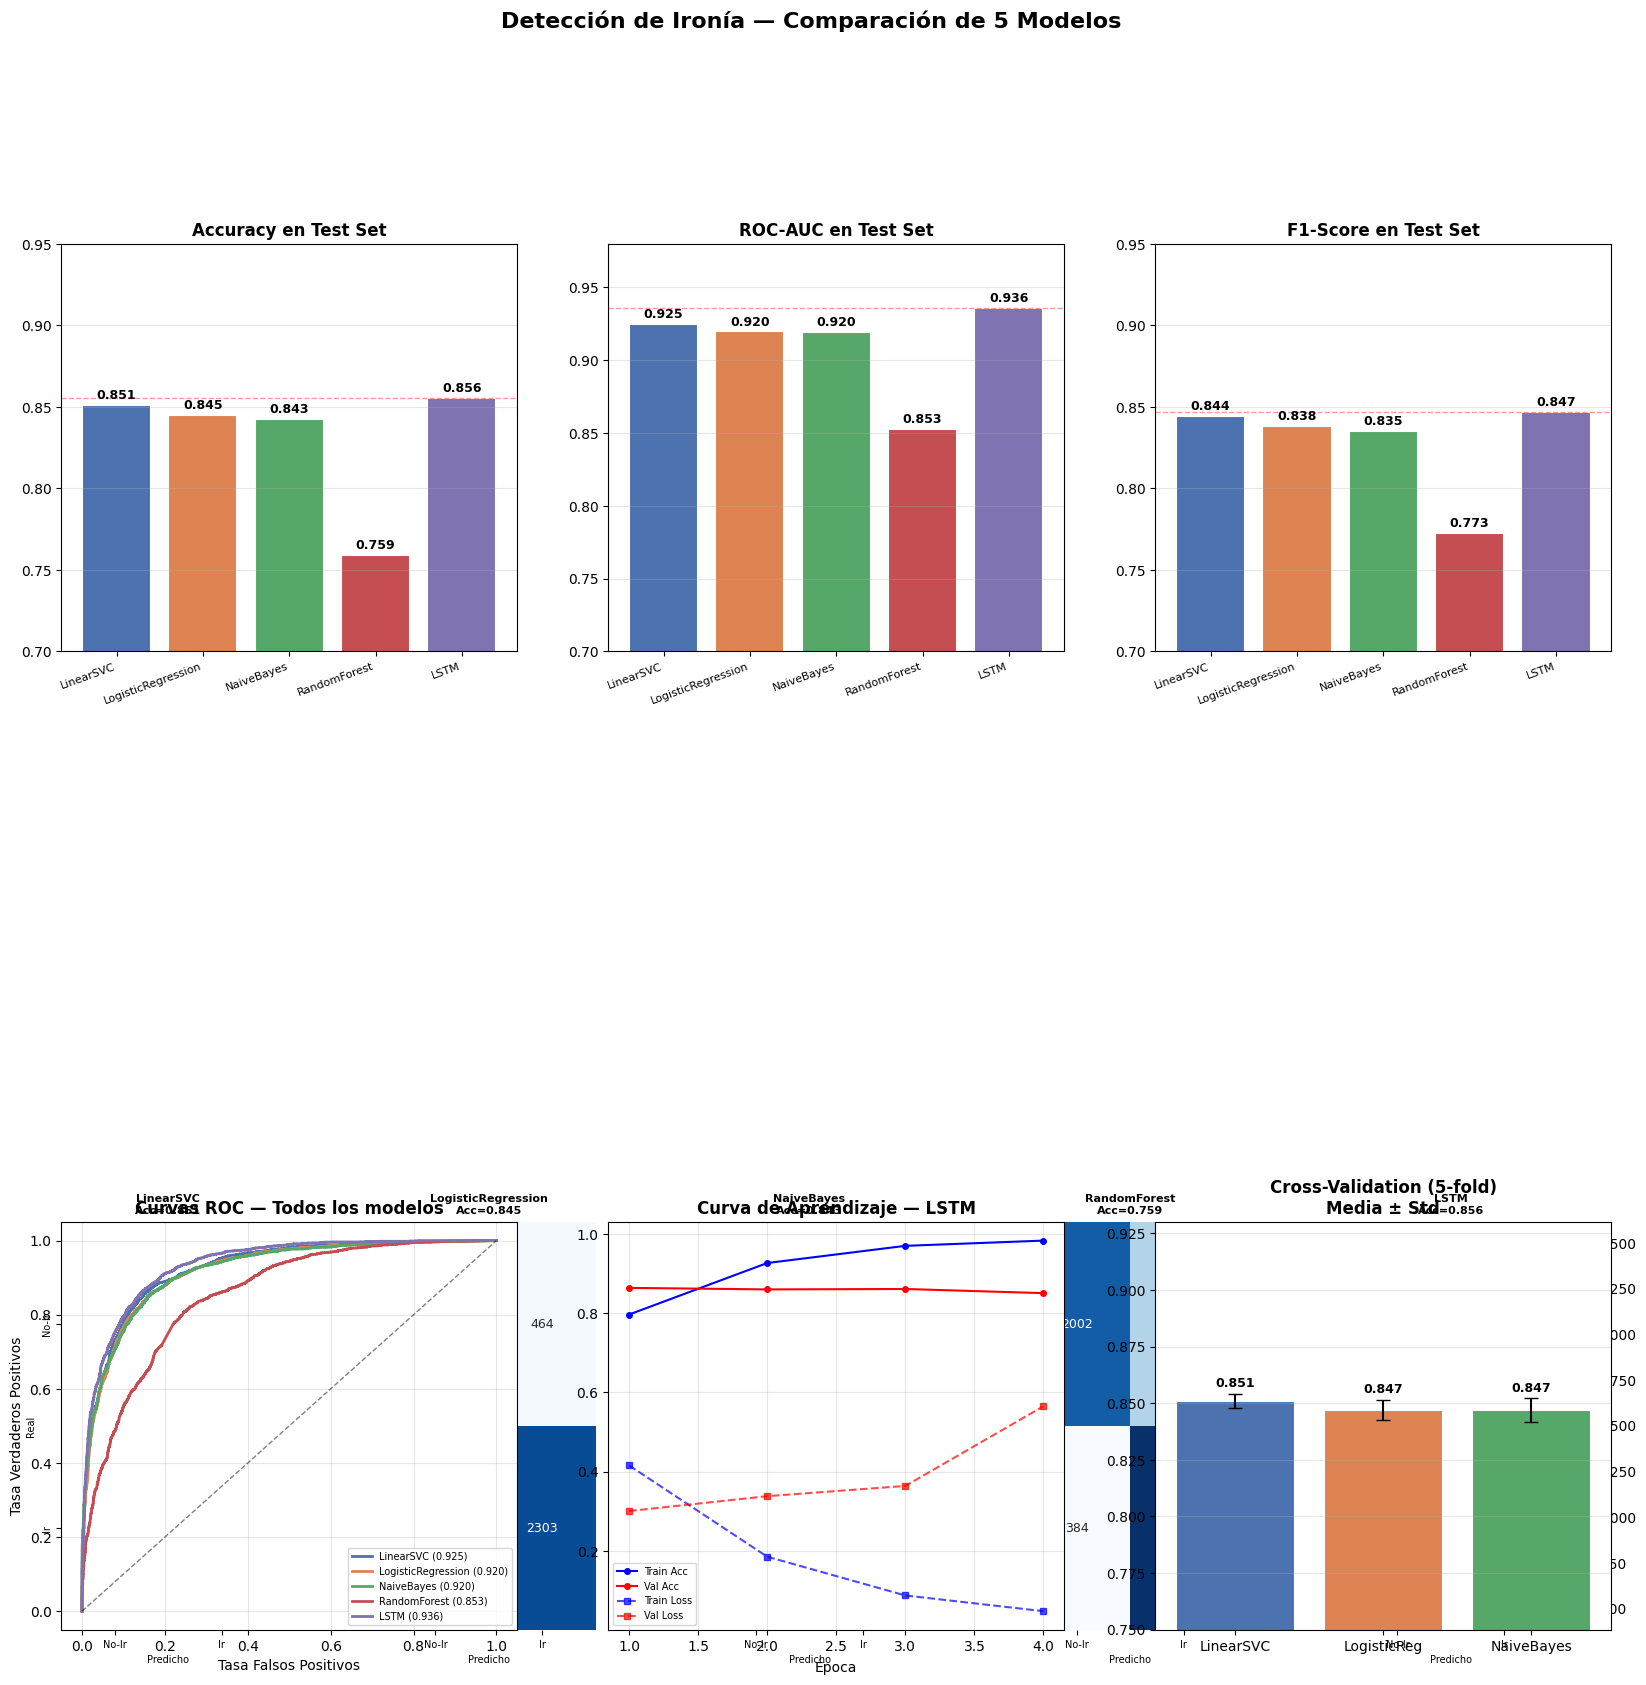

 Gráficas guardadas en: irony_5models_results.png


In [54]:

# 7. VISUALIZACIONES COMPLETAS

MODEL_NAMES = ["LinearSVC", "LogisticRegression", "NaiveBayes",
               "RandomForest", "LSTM"]
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Detección de Ironía — Comparación de 5 Modelos",
             fontsize=16, fontweight="bold", y=1.01)

# ── Plot 1: Accuracy comparativa ──
ax1 = fig.add_subplot(3, 3, 1)
accs = [results[m]["accuracy"] for m in MODEL_NAMES]
bars = ax1.bar(MODEL_NAMES, accs, color=COLORS, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_title("Accuracy en Test Set", fontweight="bold")
ax1.set_ylim(0.70, 0.95)
ax1.set_xticklabels(MODEL_NAMES, rotation=20, ha="right", fontsize=8)
ax1.axhline(max(accs), color="red", linestyle="--", alpha=0.4, linewidth=1)
ax1.grid(axis="y", alpha=0.3)

# ── Plot 2: ROC-AUC comparativa ──
ax2 = fig.add_subplot(3, 3, 2)
aucs = [results[m]["auc"] for m in MODEL_NAMES]
bars2 = ax2.bar(MODEL_NAMES, aucs, color=COLORS, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("ROC-AUC en Test Set", fontweight="bold")
ax2.set_ylim(0.70, 0.98)
ax2.set_xticklabels(MODEL_NAMES, rotation=20, ha="right", fontsize=8)
ax2.axhline(max(aucs), color="red", linestyle="--", alpha=0.4, linewidth=1)
ax2.grid(axis="y", alpha=0.3)

# ── Plot 3: F1-Score comparativa ──
ax3 = fig.add_subplot(3, 3, 3)
f1s = [results[m]["f1"] for m in MODEL_NAMES]
bars3 = ax3.bar(MODEL_NAMES, f1s, color=COLORS, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars3, f1s):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_title("F1-Score en Test Set", fontweight="bold")
ax3.set_ylim(0.70, 0.95)
ax3.set_xticklabels(MODEL_NAMES, rotation=20, ha="right", fontsize=8)
ax3.axhline(max(f1s), color="red", linestyle="--", alpha=0.4, linewidth=1)
ax3.grid(axis="y", alpha=0.3)

# ── Plots 4-8: Matrices de confusión ──
preds_all = [y_pred_svm, y_pred_lr, y_pred_nb, y_pred_rf, y_pred_lstm]
for idx, (nombre, y_pred) in enumerate(zip(MODEL_NAMES, preds_all)):
    ax = fig.add_subplot(3, 5, 11 + idx)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No-Ir", "Ir"],
                yticklabels=["No-Ir", "Ir"],
                annot_kws={"size": 9})
    ax.set_title(f"{nombre}\nAcc={results[nombre]['accuracy']:.3f}",
                 fontweight="bold", fontsize=8)
    ax.set_xlabel("Predicho", fontsize=7)
    ax.set_ylabel("Real", fontsize=7)
    ax.tick_params(labelsize=7)

# ── Plot: Curvas ROC ──
ax_roc = fig.add_subplot(3, 3, 7)
probas_all = [y_proba_svm, y_proba_lr, y_proba_nb, y_proba_rf, y_proba_lstm]
for nombre, y_proba, color in zip(MODEL_NAMES, probas_all, COLORS):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax_roc.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} ({auc:.3f})")
ax_roc.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
ax_roc.set_xlabel("Tasa Falsos Positivos")
ax_roc.set_ylabel("Tasa Verdaderos Positivos")
ax_roc.set_title("Curvas ROC — Todos los modelos", fontweight="bold")
ax_roc.legend(fontsize=7, loc="lower right")
ax_roc.grid(alpha=0.3)

# ── Plot: Curva de aprendizaje LSTM ──
ax_lstm = fig.add_subplot(3, 3, 8)
epochs = range(1, len(history.history["accuracy"]) + 1)
ax_lstm.plot(epochs, history.history["accuracy"],     "b-o", markersize=4, label="Train Acc")
ax_lstm.plot(epochs, history.history["val_accuracy"], "r-o", markersize=4, label="Val Acc")
ax_lstm.plot(epochs, history.history["loss"],         "b--s", markersize=4, label="Train Loss", alpha=0.7)
ax_lstm.plot(epochs, history.history["val_loss"],     "r--s", markersize=4, label="Val Loss", alpha=0.7)
ax_lstm.set_xlabel("Época")
ax_lstm.set_title("Curva de Aprendizaje — LSTM", fontweight="bold")
ax_lstm.legend(fontsize=7)
ax_lstm.grid(alpha=0.3)

# ── Plot: Cross-Validation ──
ax_cv = fig.add_subplot(3, 3, 9)
cv_names  = list(cv_results.keys())
cv_means  = [cv_results[k].mean() for k in cv_names]
cv_stds   = [cv_results[k].std()  for k in cv_names]
ax_cv.bar(cv_names, cv_means,
          yerr=cv_stds, capsize=5,
          color=COLORS[:3], edgecolor="white", linewidth=1.5)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax_cv.text(i, m + s + 0.003, f"{m:.3f}", ha="center",
               fontsize=9, fontweight="bold")
ax_cv.set_title("Cross-Validation (5-fold)\nMedia ± Std", fontweight="bold")
ax_cv.set_ylim(0.75, 0.93)
ax_cv.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("irony_5models_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráficas guardadas en: irony_5models_results.png")

In [55]:

# 8. PREDICCIÓN EN FRASES NUEVAS


frases_nuevas = [
    ("Man who loves his job still finds time to hate everything else",      1),
    ("New study shows regular exercise reduces risk of heart disease",      0),
    ("Local man completely fine with how everything is going",              1),
    ("Federal Reserve raises interest rates amid inflation concerns",       0),
    ("Scientists confirm sun will rise again tomorrow morning",             1),
    ("WHO warns of new flu variant spreading across Southeast Asia",        0),
    ("Nation's dogs demand explanation for suspicious behavior of vacuum",  1),
]

# Vectorizar para modelos clásicos
X_frases_tfidf = tfidf.transform([f[0] for f in frases_nuevas])
X_frases_count = count_vec.transform([f[0] for f in frases_nuevas])
X_frases_seq   = pad_sequences(
    tokenizer_lstm.texts_to_sequences([f[0] for f in frases_nuevas]),
    maxlen=MAX_LEN, padding="post"
)

# Probabilidades de cada modelo
probas_frases = {
    "SVM"  : svm.predict_proba(X_frases_tfidf)[:, 1],
    "LR"   : lr.predict_proba(X_frases_tfidf)[:, 1],
    "NB"   : nb.predict_proba(X_frases_count)[:, 1],
    "RF"   : rf.predict_proba(X_frases_tfidf)[:, 1],
    "LSTM" : lstm_model.predict(X_frases_seq, verbose=0).flatten(),
}

print(f"\n{'Frase':55} {'Real':6} | {'SVM':6} | {'LR':6} | {'NB':6} | "
      f"{'RF':6} | {'LSTM':6}")
print("─" * 100)

for i, (frase, real) in enumerate(frases_nuevas):
    etiq_real = "IRONIA" if real == 1 else "SERIO"
    preds_str = " | ".join(
        [f"{'-' if probas_frases[m][i] >= 0.5 else '-'}{probas_frases[m][i]:.2f}"
         for m in ["SVM", "LR", "NB", "RF", "LSTM"]]
    )
    print(f"{frase[:54]:55} {etiq_real:6} | {preds_str}")



Frase                                                   Real   | SVM    | LR     | NB     | RF     | LSTM  
────────────────────────────────────────────────────────────────────────────────────────────────────
Man who loves his job still finds time to hate everyth  IRONIA | -0.92 | -0.89 | -1.00 | -0.71 | -0.96
New study shows regular exercise reduces risk of heart  SERIO  | -0.63 | -0.72 | -0.99 | -0.75 | -0.87
Local man completely fine with how everything is going  IRONIA | -0.93 | -0.79 | -1.00 | -0.61 | -0.98
Federal Reserve raises interest rates amid inflation c  SERIO  | -0.42 | -0.40 | -0.02 | -0.51 | -0.79
Scientists confirm sun will rise again tomorrow mornin  IRONIA | -0.95 | -0.77 | -0.97 | -0.50 | -0.97
WHO warns of new flu variant spreading across Southeas  SERIO  | -0.66 | -0.76 | -0.86 | -0.68 | -0.84
Nation's dogs demand explanation for suspicious behavi  IRONIA | -0.97 | -0.90 | -1.00 | -0.84 | -0.99


In [56]:

# 9. TABLA RESUMEN FINAL


mejor_acc = max(results, key=lambda m: results[m]["accuracy"])
mejor_auc = max(results, key=lambda m: results[m]["auc"])
mejor_f1  = max(results, key=lambda m: results[m]["f1"])

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│              COMPARACIÓN FINAL — 5 MODELOS                         │
├──────────────────────┬──────────┬──────────┬──────────┬────────────┤
│ Modelo               │ Accuracy │  ROC-AUC │ F1-Score │   Tipo     │
├──────────────────────┼──────────┼──────────┼──────────┼────────────┤""")

tipo = {
    "LinearSVC":          "Lineal   ",
    "LogisticRegression": "Logístico",
    "NaiveBayes":         "Prob. Bay",
    "RandomForest":       "Ensemble ",
    "LSTM":               "Deep Lear"
}

for m in MODEL_NAMES:
    r = results[m]
    mark = " ◄ MEJOR" if m == mejor_acc else ""
    print(f"│ {m:20} │  {r['accuracy']:.4f}  │  {r['auc']:.4f}  │  "
          f"{r['f1']:.4f}  │ {tipo[m]}  │{mark}")

print("├──────────────────────┴──────────┴──────────┴──────────┴────────────┤")
print(f"│   Mejor Accuracy : {mejor_acc:<20}                              │")
print(f"│   Mejor ROC-AUC  : {mejor_auc:<20}                              │")
print(f"│   Mejor F1-Score : {mejor_f1:<20}                              │")
print("└───────────────────────────────────────────────────────────────────┘")

print("""
 NOTAS CLAVE:
   • LinearSVC y LogisticRegression son muy rápidos y competitivos en texto
   • NaiveBayes es el más rápido, sorprendentemente bueno con poco datos
   • RandomForest es lento con TF-IDF de alta dimensión (no su fuerte)
   • LSTM captura contexto y orden → puede superar a modelos clásicos
     pero requiere más datos y tiempo de entrenamiento
""")
print("═"*65)
print("  FIN DEL PIPELINE")
print("═"*65)


┌────────────────────────────────────────────────────────────────────┐
│              COMPARACIÓN FINAL — 5 MODELOS                         │
├──────────────────────┬──────────┬──────────┬──────────┬────────────┤
│ Modelo               │ Accuracy │  ROC-AUC │ F1-Score │   Tipo     │
├──────────────────────┼──────────┼──────────┼──────────┼────────────┤
│ LinearSVC            │  0.8513  │  0.9248  │  0.8444  │ Lineal     │
│ LogisticRegression   │  0.8449  │  0.9198  │  0.8384  │ Logístico  │
│ NaiveBayes           │  0.8426  │  0.9196  │  0.8351  │ Prob. Bay  │
│ RandomForest         │  0.7591  │  0.8527  │  0.7726  │ Ensemble   │
│ LSTM                 │  0.8555  │  0.9358  │  0.8467  │ Deep Lear  │ ◄ MEJOR
├──────────────────────┴──────────┴──────────┴──────────┴────────────┤
│   Mejor Accuracy : LSTM                                              │
│   Mejor ROC-AUC  : LSTM                                              │
│   Mejor F1-Score : LSTM                                       